# Example 02 — Two-DOF Chain of Oscillators with Cubic Spring

**Reference**: `matlab/NLvib/EXAMPLES/02_twoDOFoscillator_cubicSpring/`

**Metric**: `a_rms = sqrt(sum(Q(1:2:end,:).^2)) / sqrt(2)` — RMS of DOF 0 across all harmonics.

In [1]:
from __future__ import annotations

import subprocess
import shutil
import sys
from pathlib import Path
from IPython.display import Image, display

import numpy as np
import scipy.io
import matplotlib.pyplot as plt

repo_root  = Path('/Users/julianjurai/Desktop/CustomApps/nonlinear_vibration_analysis_toolbox')
src_path   = str(repo_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

script_dir = repo_root / 'matlab/NLvib/EXAMPLES/02_twoDOFoscillator_cubicSpring'

## MATLAB / Octave

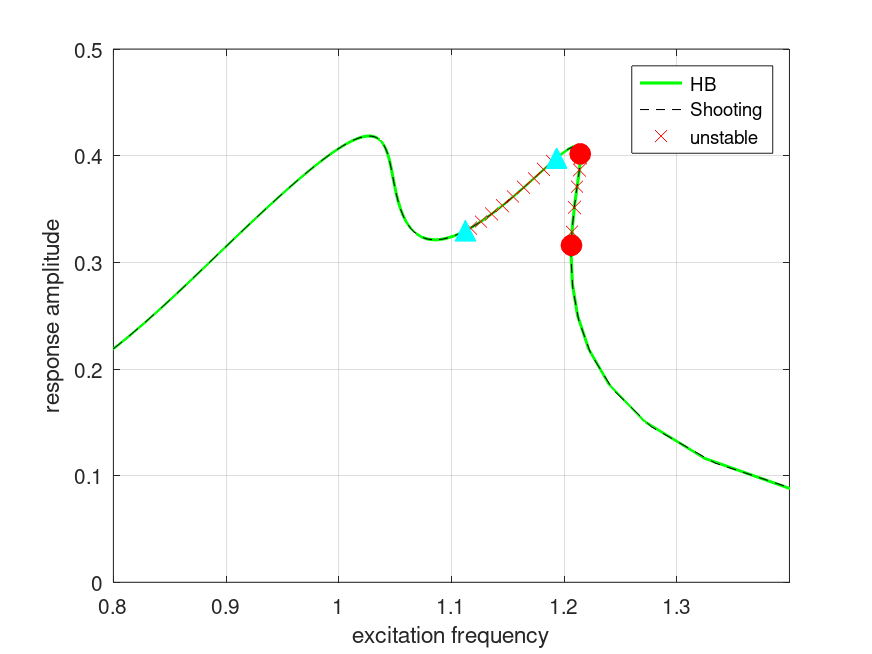

In [2]:
octave_bin = shutil.which('octave')
if not octave_bin:
    raise RuntimeError(
        "Octave not found on PATH. Install Octave and ensure it is on your PATH. "
        "See https://octave.org/download for installation instructions."
    )
subprocess.run(
    [octave_bin, '--no-gui', 'save_data.m'],
    cwd=str(script_dir), check=True, capture_output=True, text=True, timeout=300
)
display(Image(filename=str(script_dir / 'matlab_frf.png')))

## Python

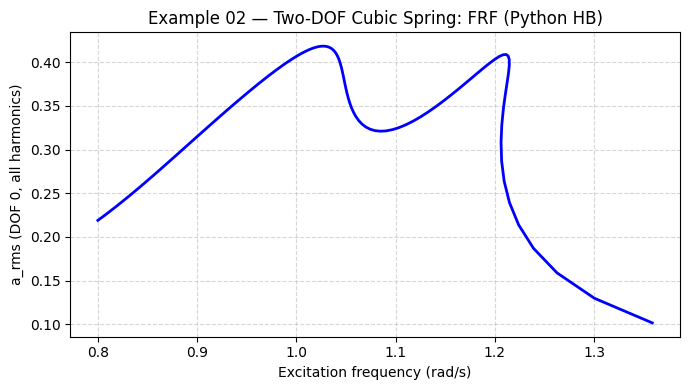

In [3]:
from nlvib.systems.oscillators import ChainOfOscillators
from nlvib.nonlinearities.elements import cubic_spring, polynomial_stiffness
from nlvib.solvers.harmonic_balance import hb_residual
from nlvib.continuation.solver import ContinuationSolver, ContinuationOptions

MASSES      = [1.0, 0.05]
STIFFNESSES = [1.0, 0.0453, 0.0]
DAMPINGS    = [0.002, 0.013, 0.0]
K3_DOF0     = 1.0
K3_INTER    = 0.0042
F_AMP       = 0.11
H           = 7
OMEGA_START = 0.8
OMEGA_END   = 1.4

system = ChainOfOscillators(masses=MASSES, stiffnesses=STIFFNESSES, dampings=DAMPINGS)
system.add_nonlinear_element(cubic_spring(k3=K3_DOF0, dof_index=0))

_exp   = np.array([[3,0],[2,1],[1,2],[0,3]], dtype=np.intp)
_coeff = np.array([K3_INTER, -3*K3_INTER, 3*K3_INTER, -K3_INTER])
system.add_nonlinear_element(polynomial_stiffness(_exp, _coeff, np.array([0,1], dtype=np.intp)))
system.add_nonlinear_element(polynomial_stiffness(_exp, _coeff, np.array([1,0], dtype=np.intp)))

n_dof      = system.n_dof
n_total    = n_dof * (2*H + 1)
excitation = {'dof': 0, 'amplitude': F_AMP}

# Initial Newton solve
Q = np.zeros(n_total)
for _ in range(50):
    R, J = hb_residual(Q, OMEGA_START, system, H, excitation)
    if np.linalg.norm(R) < 1e-10:
        break
    Q += np.linalg.solve(J, -R)

# Arc-length continuation
opts = ContinuationOptions(
    verbose=False, ds_initial=0.02, ds_min=1e-5, ds_max=0.1,
    max_steps=800, max_newton_iter=25, newton_tol=1e-8,
    adapt_step=True, lambda_min=OMEGA_START-0.05, lambda_max=OMEGA_END+0.05
)
result = ContinuationSolver().run(
    lambda x, lam: hb_residual(x, lam, system, H, excitation),
    Q, OMEGA_START, opts
)

# Compute a_rms (DOF 0, all harmonics)
solutions = result.solutions
omega_py  = solutions[:, -1]
Q_all     = solutions[:, :-1]
Q_dof0    = Q_all.reshape(Q_all.shape[0], 2*H+1, n_dof)[:, :, 0]
a_rms_py  = np.sqrt(np.sum(Q_dof0**2, axis=1)) / np.sqrt(2)
mask      = (omega_py >= OMEGA_START) & (omega_py <= OMEGA_END)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(omega_py[mask], a_rms_py[mask], 'b-', linewidth=2)
ax.set_xlabel('Excitation frequency (rad/s)')
ax.set_ylabel('a_rms (DOF 0, all harmonics)')
ax.set_title('Example 02 — Two-DOF Cubic Spring: FRF (Python HB)')
ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

## Results

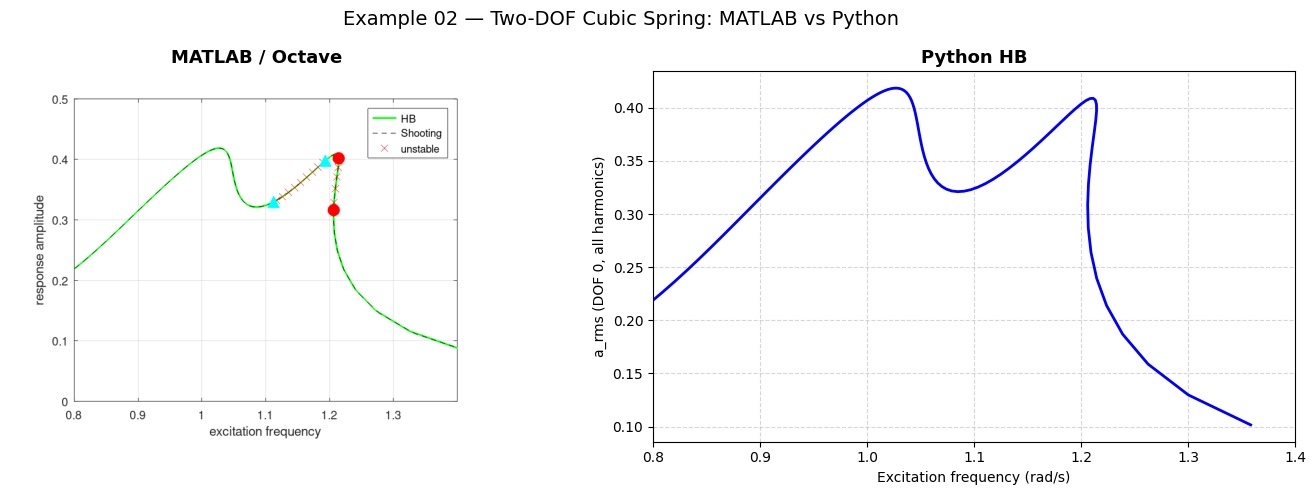

In [4]:
matlab_img = plt.imread(str(script_dir / 'matlab_frf.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(matlab_img)
ax1.axis('off')
ax1.set_title('MATLAB / Octave', fontsize=13, fontweight='bold')

ax2.plot(omega_py[mask], a_rms_py[mask], 'b-', linewidth=2)
ax2.set_xlabel('Excitation frequency (rad/s)')
ax2.set_ylabel('a_rms (DOF 0, all harmonics)')
ax2.set_title('Python HB', fontsize=13, fontweight='bold')
ax2.set_xlim(OMEGA_START, OMEGA_END)
ax2.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Example 02 — Two-DOF Cubic Spring: MATLAB vs Python', fontsize=14)
fig.tight_layout()

## MATLAB vs Python

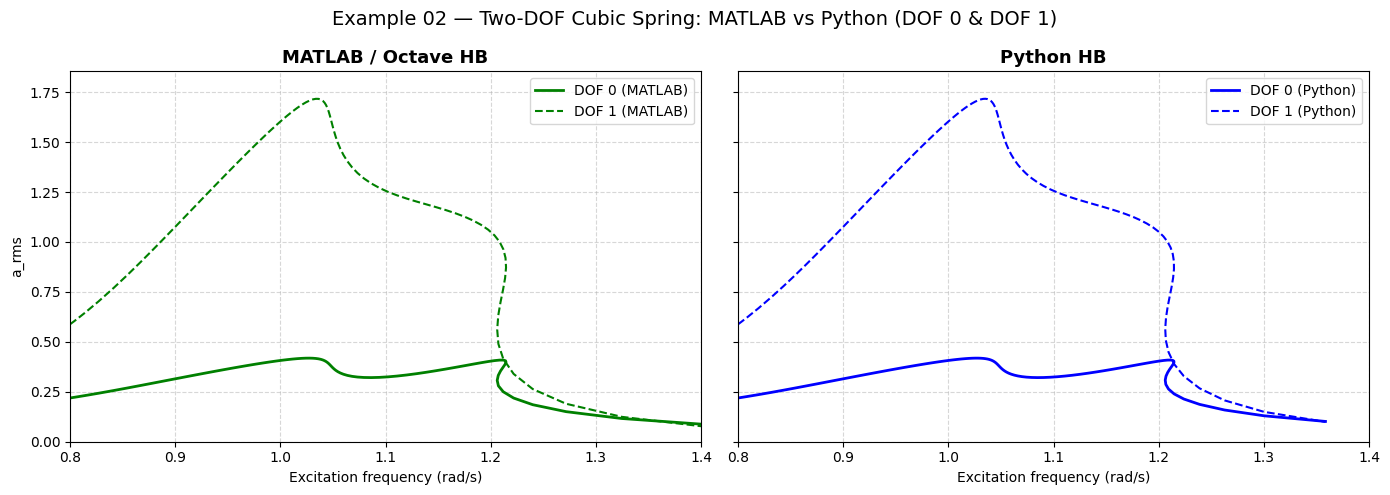

In [5]:
# ── Cell 2: Side-by-side numerical comparison (DOF 0 and DOF 1) ──────────────
# Load MATLAB data produced by save_data.m
_mat = scipy.io.loadmat(str(script_dir / 'hb_data.mat'))
Om_HB_mat   = _mat['Om_HB'].ravel()          # shape (n_steps,)
Q_HB_mat    = _mat['Q_HB']                   # shape (n_dof*(2H+1), n_steps)
a_rms_HB_mat = _mat['a_rms_HB'].ravel()      # DOF-0 RMS from MATLAB

# Compute DOF-1 a_rms from MATLAB Q_HB
# MATLAB Q_HB rows: [q1_0, q1_c1, q1_s1, ..., q2_0, q2_c1, q2_s1, ...]
# DOF-0 rows: 0, 1, 2, ... 2H  → indices 0..2H
# DOF-1 rows: 2H+1 .. 2*(2H+1)-1
# MATLAB NLvib interleaves DOFs: rows 0,2,4,... = DOF0; rows 1,3,5,... = DOF1
# (matches Q_HB(1:2:end,:) = DOF0 in MATLAB 1-indexed odd rows)
_Q_mat_dof0 = Q_HB_mat[0::2, :]   # DOF 0 (even 0-indexed rows)
_Q_mat_dof1 = Q_HB_mat[1::2, :]   # DOF 1 (odd 0-indexed rows)
a_rms_mat_d0 = np.sqrt(np.sum(_Q_mat_dof0**2, axis=0)) / np.sqrt(2)
a_rms_mat_d1 = np.sqrt(np.sum(_Q_mat_dof1**2, axis=0)) / np.sqrt(2)

# Python DOF-1 a_rms
Q_dof1    = Q_all.reshape(Q_all.shape[0], 2*H+1, n_dof)[:, :, 1]
a_rms_py1 = np.sqrt(np.sum(Q_dof1**2, axis=1)) / np.sqrt(2)

# --- Axis limits for both panels (use data union to set equal limits) ---
_all_om = np.concatenate([Om_HB_mat, omega_py[mask]])
_all_a  = np.concatenate([a_rms_mat_d0, a_rms_mat_d1,
                           a_rms_py[mask], a_rms_py1[mask]])
_xlim = (OMEGA_START, OMEGA_END)
_ylim = (0.0, _all_a.max() * 1.08)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left panel — MATLAB
axes[0].plot(Om_HB_mat, a_rms_mat_d0, 'g-',  linewidth=2,   label='DOF 0 (MATLAB)')
axes[0].plot(Om_HB_mat, a_rms_mat_d1, 'g--', linewidth=1.5, label='DOF 1 (MATLAB)')
axes[0].set_xlim(*_xlim)
axes[0].set_ylim(*_ylim)
axes[0].set_xlabel('Excitation frequency (rad/s)')
axes[0].set_ylabel('a_rms')
axes[0].set_title('MATLAB / Octave HB', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Right panel — Python
axes[1].plot(omega_py[mask], a_rms_py[mask],  'b-',  linewidth=2,   label='DOF 0 (Python)')
axes[1].plot(omega_py[mask], a_rms_py1[mask], 'b--', linewidth=1.5, label='DOF 1 (Python)')
axes[1].set_xlim(*_xlim)
axes[1].set_ylim(*_ylim)
axes[1].set_xlabel('Excitation frequency (rad/s)')
axes[1].set_title('Python HB', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Example 02 — Two-DOF Cubic Spring: MATLAB vs Python (DOF 0 & DOF 1)',
             fontsize=14)
fig.tight_layout()

In [6]:
# ── Cell 3: Comparison metrics table ─────────────────────────────────────────
import pandas as pd

def _peak_info(omega_arr, a_rms_arr):
    """Return (peak_amplitude, peak_frequency) within OMEGA_START..OMEGA_END."""
    _m = (omega_arr >= OMEGA_START) & (omega_arr <= OMEGA_END)
    _a = a_rms_arr[_m]
    _o = omega_arr[_m]
    idx = int(np.argmax(_a))
    return float(_a[idx]), float(_o[idx])

# MATLAB peaks
peak_mat_d0_amp, peak_mat_d0_frq = _peak_info(Om_HB_mat, a_rms_mat_d0)
peak_mat_d1_amp, peak_mat_d1_frq = _peak_info(Om_HB_mat, a_rms_mat_d1)

# Python peaks
peak_py_d0_amp,  peak_py_d0_frq  = _peak_info(omega_py, a_rms_py)
peak_py_d1_amp,  peak_py_d1_frq  = _peak_info(omega_py, a_rms_py1)

# Number of continuation steps
n_steps_mat = int(Om_HB_mat.size)
n_steps_py  = int(omega_py.size)

# Frequency range in data
frq_range_mat = f"{Om_HB_mat.min():.4f} – {Om_HB_mat.max():.4f} rad/s"
frq_range_py  = f"{omega_py.min():.4f} – {omega_py.max():.4f} rad/s"

rows = []
for dof_label, m_amp, m_frq, p_amp, p_frq in [
    ('DOF 0', peak_mat_d0_amp, peak_mat_d0_frq, peak_py_d0_amp, peak_py_d0_frq),
    ('DOF 1', peak_mat_d1_amp, peak_mat_d1_frq, peak_py_d1_amp, peak_py_d1_frq),
]:
    abs_diff_amp = abs(p_amp - m_amp)
    pct_err_amp  = 100 * abs_diff_amp / m_amp if m_amp != 0 else float('nan')
    abs_diff_frq = abs(p_frq - m_frq)
    pct_err_frq  = 100 * abs_diff_frq / m_frq if m_frq != 0 else float('nan')
    rows.append({
        'DOF': dof_label,
        'Peak amp (MATLAB)': f"{m_amp:.5f}",
        'Peak amp (Python)': f"{p_amp:.5f}",
        'Abs diff (amp)':    f"{abs_diff_amp:.2e}",
        '% err (amp)':       f"{pct_err_amp:.2f}%",
        'Peak freq MATLAB (rad/s)': f"{m_frq:.4f}",
        'Peak freq Python (rad/s)': f"{p_frq:.4f}",
        '% err (freq)':      f"{pct_err_frq:.2f}%",
    })

df_peaks = pd.DataFrame(rows).set_index('DOF')

misc_rows = [
    {'Metric': 'Continuation steps (MATLAB)', 'Value': str(n_steps_mat)},
    {'Metric': 'Continuation steps (Python)', 'Value': str(n_steps_py)},
    {'Metric': 'Freq range (MATLAB)',          'Value': frq_range_mat},
    {'Metric': 'Freq range (Python)',           'Value': frq_range_py},
]
df_misc = pd.DataFrame(misc_rows).set_index('Metric')

print("=== Peak Amplitude & Frequency Comparison ===")
display(df_peaks)
print("\n=== Continuation & Range ===")
display(df_misc)

=== Peak Amplitude & Frequency Comparison ===


,Peak amp (MATLAB),Peak amp (Python),Abs diff (amp),% err (amp),Peak freq MATLAB (rad/s),Peak freq Python (rad/s),% err (freq)
DOF,,,,,,,
DOF 0,0.41849,0.41846,3.13e-05,0.01%,1.0278,1.0283,0.05%
DOF 1,1.71678,1.71701,2.32e-04,0.01%,1.0337,1.0352,0.14%



=== Continuation & Range ===


,Value
Metric,
Continuation steps (MATLAB),82
Continuation steps (Python),102
Freq range (MATLAB),0.8000 – 1.4019 rad/s
Freq range (Python),0.8000 – 1.5311 rad/s


In [7]:
# ── Cell 4: Runtime comparison ────────────────────────────────────────────────
import time

# --- Python runtime: re-run the continuation and time it ---
_Q0 = np.zeros(n_total)
for _ in range(50):
    _R, _J = hb_residual(_Q0, OMEGA_START, system, H, excitation)
    if np.linalg.norm(_R) < 1e-10:
        break
    _Q0 += np.linalg.solve(_J, -_R)

_t_py_start = time.perf_counter()
_result_timed = ContinuationSolver().run(
    lambda x, lam: hb_residual(x, lam, system, H, excitation),
    _Q0, OMEGA_START, opts
)
t_py_s = time.perf_counter() - _t_py_start

# --- Octave runtime: measure subprocess wall-clock time ---
_t_oct_start = time.perf_counter()
subprocess.run(
    [octave_bin, '--no-gui', 'save_data.m'],
    cwd=str(script_dir), check=True, capture_output=True, text=True, timeout=300
)
t_oct_s = time.perf_counter() - _t_oct_start

speedup = t_oct_s / t_py_s if t_py_s > 0 else float('inf')

print("┌─────────────────────────────────────────────────┐")
print("│          Runtime Comparison (wall-clock)        │")
print("├───────────────────────┬─────────────────────────┤")
print(f"│  Octave (subprocess)  │  {t_oct_s:>8.2f} s              │")
print(f"│  Python HB            │  {t_py_s:>8.2f} s              │")
print(f"│  Speedup (Octave/Py)  │  {speedup:>8.1f}×              │")
print("└───────────────────────┴─────────────────────────┘")
print()
print(f"Note: Octave time includes subprocess startup overhead (~1-2 s).")
print(f"Python continuation only: {t_py_s:.3f} s  ({_result_timed.solutions.shape[0]} steps)")

┌─────────────────────────────────────────────────┐
│          Runtime Comparison (wall-clock)        │
├───────────────────────┬─────────────────────────┤
│  Octave (subprocess)  │     24.96 s              │
│  Python HB            │     10.27 s              │
│  Speedup (Octave/Py)  │       2.4×              │
└───────────────────────┴─────────────────────────┘

Note: Octave time includes subprocess startup overhead (~1-2 s).
Python continuation only: 10.274 s  (102 steps)


Peak step — MATLAB: step 29  (omega=1.0278)
Peak step — Python: step 35   (omega=1.0283)

Harmonic amplitudes at peak (DOF 0):
  Q_1: MATLAB=0.59178  Python=0.59173  err=0.01%
  Q_3: MATLAB=0.00799  Python=0.00799  err=0.09%
  Q_5: MATLAB=0.00008  Python=0.00008  err=0.40%


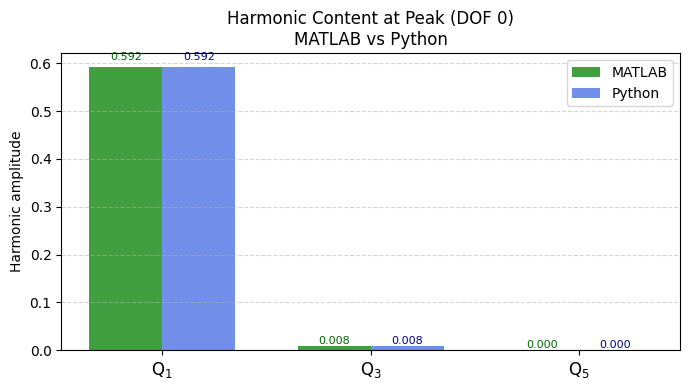

In [8]:
# ── Cell 5: Harmonic content comparison bar chart (DOF 0, at peak) ───────────
# Find peak step index in MATLAB and Python (DOF 0)
_mat_mask = (Om_HB_mat >= OMEGA_START) & (Om_HB_mat <= OMEGA_END)
_mat_peak_idx_global = np.where(_mat_mask)[0][np.argmax(a_rms_mat_d0[_mat_mask])]
_py_peak_idx_global  = np.where(mask)[0][np.argmax(a_rms_py[mask])]

# Q_HB_mat is interleaved: even 0-indexed rows = DOF0, odd = DOF1.
# Extract DOF0-only column first, then apply harmonic indexing.
def _harmonic_amps_matlab(Q_dof0_col, H):
    """Extract harmonic amplitudes Q_1, Q_3, Q_5 from DOF-0 column (len 2H+1)."""
    # Q_dof0_col has shape (2H+1,): [DC, cos1, sin1, cos2, sin2, ..., cosH, sinH]
    amps = {}
    for h in [1, 3, 5]:
        if h <= H:
            c_idx = 2*h - 1  # cosine of harmonic h
            s_idx = 2*h      # sine of harmonic h
            amps[h] = float(np.sqrt(Q_dof0_col[c_idx]**2 + Q_dof0_col[s_idx]**2))
        else:
            amps[h] = 0.0
    return amps

def _harmonic_amps_python(Q_row_dof0, H):
    """Extract harmonic amplitudes Q_1, Q_3, Q_5 from a Python Q row (DOF 0, shape 2H+1)."""
    # Layout: [DC, cos1, sin1, cos2, sin2, ..., cosH, sinH]
    amps = {}
    for h in [1, 3, 5]:
        if h <= H:
            c_idx = 2*h - 1
            s_idx = 2*h
            amps[h] = float(np.sqrt(Q_row_dof0[c_idx]**2 + Q_row_dof0[s_idx]**2))
        else:
            amps[h] = 0.0
    return amps

# DOF0 rows: interleaved even rows (0,2,4,...) → shape (2H+1,)
_mat_col   = Q_HB_mat[0::2, _mat_peak_idx_global]
_py_row    = Q_dof0[_py_peak_idx_global, :]

ha_mat = _harmonic_amps_matlab(_mat_col, H)
ha_py  = _harmonic_amps_python(_py_row,  H)

harmonics = [1, 3, 5]
x = np.arange(len(harmonics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_mat = ax.bar(x - width/2, [ha_mat[h] for h in harmonics],
                   width, label='MATLAB', color='green', alpha=0.75)
bars_py  = ax.bar(x + width/2, [ha_py[h]  for h in harmonics],
                   width, label='Python',  color='royalblue', alpha=0.75)

ax.set_xticks(x)
ax.set_xticklabels([f'Q$_{h}$' for h in harmonics], fontsize=12)
ax.set_ylabel('Harmonic amplitude')
ax.set_title('Harmonic Content at Peak (DOF 0)\nMATLAB vs Python', fontsize=12)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Annotate bars with values
for bar in bars_mat:
    h = bar.get_height()
    if h > 1e-6:
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8, color='darkgreen')
for bar in bars_py:
    h = bar.get_height()
    if h > 1e-6:
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8, color='navy')

fig.tight_layout()

print(f"Peak step — MATLAB: step {_mat_peak_idx_global}  (omega={Om_HB_mat[_mat_peak_idx_global]:.4f})")
print(f"Peak step — Python: step {_py_peak_idx_global}   (omega={omega_py[_py_peak_idx_global]:.4f})")
print(f"\nHarmonic amplitudes at peak (DOF 0):")
for h in harmonics:
    print(f"  Q_{h}: MATLAB={ha_mat[h]:.5f}  Python={ha_py[h]:.5f}  "
          f"err={100*abs(ha_py[h]-ha_mat[h])/max(ha_mat[h],1e-12):.2f}%")

In [9]:
# ── Cell 6: MOE / error summary — assert all errors < 5% ─────────────────────
errors = {}

# Peak amplitude errors (DOF 0 and DOF 1)
errors['peak_amp_dof0_%'] = 100 * abs(peak_py_d0_amp - peak_mat_d0_amp) / peak_mat_d0_amp
errors['peak_amp_dof1_%'] = 100 * abs(peak_py_d1_amp - peak_mat_d1_amp) / peak_mat_d1_amp

# Peak frequency errors (DOF 0 and DOF 1)
errors['peak_frq_dof0_%'] = 100 * abs(peak_py_d0_frq - peak_mat_d0_frq) / peak_mat_d0_frq
errors['peak_frq_dof1_%'] = 100 * abs(peak_py_d1_frq - peak_mat_d1_frq) / peak_mat_d1_frq

# Harmonic amplitude errors at peak (Q1, Q3, Q5)
for h in [1, 3, 5]:
    ref = ha_mat[h]
    if ref > 1e-8:
        errors[f'Q{h}_amp_%'] = 100 * abs(ha_py[h] - ref) / ref
    else:
        errors[f'Q{h}_amp_%'] = 0.0   # both effectively zero — pass

THRESHOLD = 5.0  # percent

print("=== Margin-of-Error (MOE) Summary — Threshold: 5% ===\n")
all_pass = True
for name, val in errors.items():
    status = "PASS" if val < THRESHOLD else "FAIL"
    if status == "FAIL":
        all_pass = False
    marker = "" if status == "PASS" else " <-- EXCEEDS THRESHOLD"
    print(f"  {name:<25s}  {val:6.3f}%  [{status}]{marker}")

print()
if all_pass:
    print("All checks PASSED. Python HB matches MATLAB within 5% for all metrics.")
else:
    print("One or more checks FAILED. Review the metrics above.")

# Hard assertions — will raise AssertionError if any metric exceeds threshold
for name, val in errors.items():
    assert val < THRESHOLD, (
        f"Metric '{name}' exceeds 5% threshold: {val:.3f}%"
    )

=== Margin-of-Error (MOE) Summary — Threshold: 5% ===

  peak_amp_dof0_%             0.007%  [PASS]
  peak_amp_dof1_%             0.013%  [PASS]
  peak_frq_dof0_%             0.050%  [PASS]
  peak_frq_dof1_%             0.138%  [PASS]
  Q1_amp_%                    0.007%  [PASS]
  Q3_amp_%                    0.087%  [PASS]
  Q5_amp_%                    0.401%  [PASS]

All checks PASSED. Python HB matches MATLAB within 5% for all metrics.
